# P2 — Quantum Phase Estimation
**Qiskit demonstration** · Quantum Computing, University of Verona, AA 2025–2026  
Usama Ahmad · VR513221 · Prof. Alessandra Di Pierro

Estimate the eigenphase of $U = CR_\varphi$ on the eigenvector $|11\rangle$:

$$
CR_\varphi |11\rangle = e^{i\varphi}|11\rangle = e^{2\pi i \vartheta}|11\rangle
\qquad\Rightarrow\qquad
\vartheta = \frac{\varphi}{2\pi}
$$

Two exact instances with 3 phase qubits:

- $\varphi = \pi/2$ $\rightarrow$ $\vartheta = 1/4 = 0.010_2$
- $\varphi = \pi/4$ $\rightarrow$ $\vartheta = 1/8 = 0.001_2$


## 1. Setup

In [1]:
import numpy as np
from qpe import build_qpe
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

backend = AerSimulator()
print("Aer simulator ready")

Aer simulator ready


## 2. Instance $\varphi = \pi/2$

$\vartheta = (\pi/2)/(2\pi) = 1/4$. With 3 bits this is the integer $m = 2$, bitstring `010`.

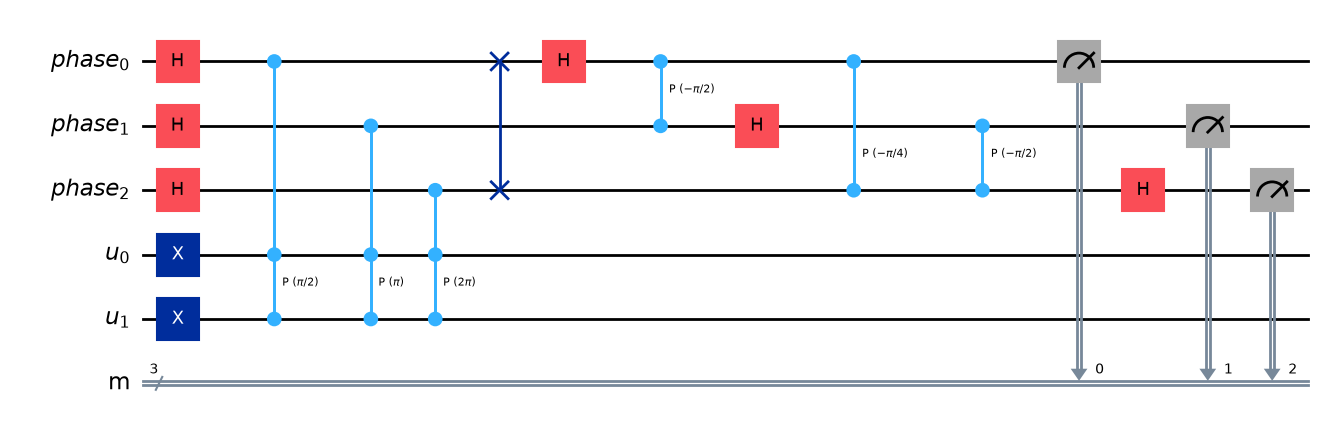

counts: {'010': 2048}
estimate θ = 2/8 = 0.25


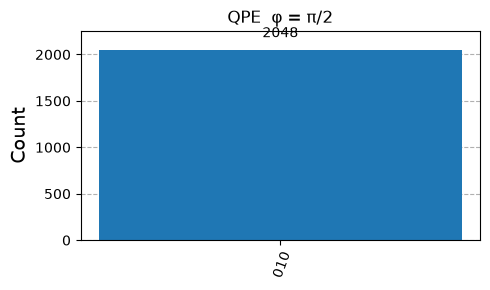

In [2]:
qc = build_qpe(np.pi / 2, n_phase=3)
display(qc.draw("mpl", fold=90))
counts = backend.run(transpile(qc, backend), shots=2048).result().get_counts()
print("counts:", counts)
m = int(max(counts, key=counts.get), 2)
print(f"estimate θ = {m}/8 = {m/8}")
display(plot_histogram(counts, title=r"QPE  φ = π/2", figsize=(5, 3)))

## 3. Instance $\varphi = \pi/4$

$\vartheta = (\pi/4)/(2\pi) = 1/8$. Integer $m = 1$, bitstring `001`.

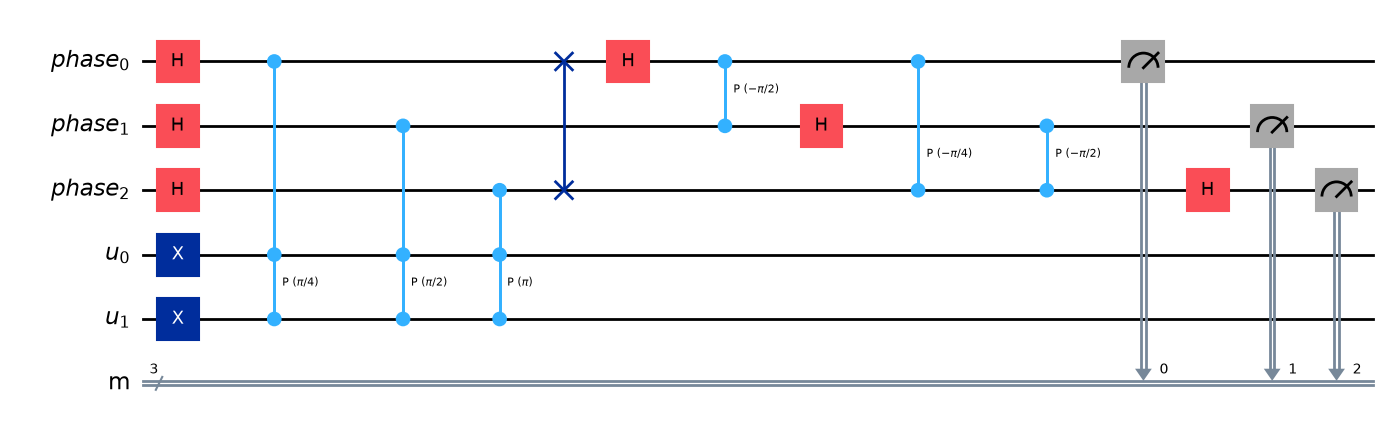

counts: {'001': 2048}
estimate θ = 1/8 = 0.125


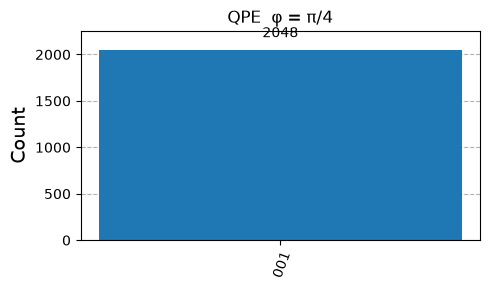

In [3]:
qc = build_qpe(np.pi / 4, n_phase=3)
display(qc.draw("mpl", fold=90))
counts = backend.run(transpile(qc, backend), shots=2048).result().get_counts()
print("counts:", counts)
m = int(max(counts, key=counts.get), 2)
print(f"estimate θ = {m}/8 = {m/8}")
display(plot_histogram(counts, title=r"QPE  φ = π/4", figsize=(5, 3)))

## 4. Summary

| $\varphi$ | True $\vartheta$ | Measured | $\vartheta$ estimate | Shots |
|---|---|---|---|---|
| $\pi/2$ | $1/4$ | `010` $= 2/8$ | $0.250$ | all 2048 |
| $\pi/4$ | $1/8$ | `001` $= 1/8$ | $0.125$ | all 2048 |

The same circuit is in `qpe.py` (`python qpe.py`).